In [1]:
import pandas as pd
train = pd.read_csv('train_data.csv')

C:\Users\pc\AppData\Local\Temp\ipykernel_4152\758484573.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train_data.csv')


In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


In [3]:
train_1 = train.copy()
train_1 = train_1.dropna(subset=['summary'])
train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838868 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838868 non-null  int64 
 1   vote            191449 non-null  object
 2   verified        838868 non-null  bool  
 3   reviewTime      838868 non-null  object
 4   reviewerID      838868 non-null  object
 5   asin            838868 non-null  object
 6   style           490574 non-null  object
 7   reviewerName    838641 non-null  object
 8   reviewText      838868 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838868 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 71.2+ MB


In [4]:
X_train=train_1['reviewText']
Y_train=train_1['overall']
print(X_train,Y_train)

0         I have an older URC-WR7 remote and thought thi...
1         First time I've EVER had a remote that needed ...
2         Got them and only 2 of them worked. company ca...
3         I got tired of the remote being on the wrong s...
4         After purchasing cheap cords from another webs...
                                ...                        
838939    These are my favorite charging cords for a few...
838940    Update....after 2 months of gentle use, cable ...
838941    These are okay. The connection becomes very if...
838942    Ok here is an odd thing that happened to me, I...
838943    I have it plugged into a usb extension on my g...
Name: reviewText, Length: 838868, dtype: object 0         2
1         5
2         4
3         5
4         5
         ..
838939    5
838940    1
838941    3
838942    5
838943    5
Name: overall, Length: 838868, dtype: int64


In [5]:
import re
import string

def clean_text(text):
    # حذف لینک‌ها
    text = re.sub(r"http\S+|www\S+", "", text)

    # حذف اعداد
    text = re.sub(r"\d+", "", text)

    # حذف علائم نگارشی
    text = text.translate(str.maketrans("", "", string.punctuation))

    # حذف فاصله‌های اضافه و تبدیل به حروف کوچک
    text = text.lower().strip()

    return text

# اعمال روی داده‌ها
X_train_clean = X_train.apply(clean_text)

In [6]:
import pandas as pd
from sklearn.utils import resample

# 1️⃣ ترکیب داده‌ها در یک DataFrame
train_df = pd.DataFrame({
    'text': X_train_clean,
    'label': Y_train
})

# 2️⃣ جدا کردن هر کلاس
dfs = [train_df[train_df['label'] == i] for i in sorted(train_df['label'].unique())]

# 3️⃣ پیدا کردن اندازه‌ی بزرگ‌ترین کلاس
max_len = max(len(d) for d in dfs)
print("بیشترین اندازه کلاس:", max_len)

# 4️⃣ Oversample همه کلاس‌ها تا اندازه‌ی بزرگ‌ترین کلاس
dfs_balanced = [
    resample(d, replace=True, n_samples=max_len, random_state=42)
    for d in dfs
]

# 5️⃣ ترکیب و Shuffle
train_balanced = pd.concat(dfs_balanced)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 6️⃣ خروجی نهایی
X_train_balanced = train_balanced['text'].tolist()
y_train_balanced = train_balanced['label'].tolist()

print(train_balanced['label'].value_counts())


بیشترین اندازه کلاس: 461440
label
1    461440
4    461440
3    461440
5    461440
2    461440
Name: count, dtype: int64


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB_SIZE = 10000    # تعداد واژه‌هایی که نگه می‌داریم
MAX_SEQ_LEN = 50      # طول هر جمله بعد از padding

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_balanced)

X_train_seq = tokenizer.texts_to_sequences(X_train_balanced)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

In [8]:
from sklearn.model_selection import train_test_split

X_train_pad, X_val_pad, y_train, y_val = train_test_split( X_train_pad, y_train_balanced, test_size=0.25, random_state=42)

C:\Users\pc\AppData\Local\Temp\ipykernel_4152\1856500683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='overall', data=train_1, palette='viridis')


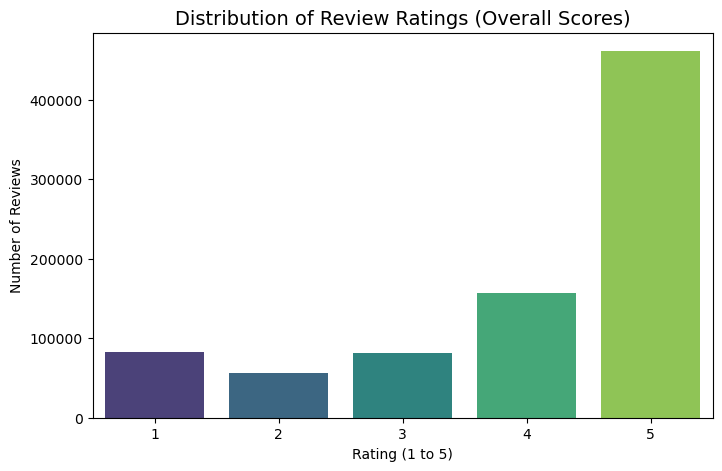

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='overall', data=train_1, palette='viridis')

plt.title('Distribution of Review Ratings (Overall Scores)', fontsize=14)
plt.xlabel('Rating (1 to 5)')
plt.ylabel('Number of Reviews')
plt.show()

In [11]:
from tensorflow.keras.utils import to_categorical
import numpy as np
y = np.array(y_train).astype(int)
y = y - 1                     
y_train_cat = to_categorical(y, num_classes=5)
y_v = np.array(y_val).astype(int)
y_v -=  1                     
y_val_cat = to_categorical(y_v, num_classes=5)



# model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow import keras
import tensorflow as tf

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
embedding_dim = 128  # اندازه‌ی بردار هر واژه

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_SEQ_LEN),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(5, activation='softmax')])
model.compile(
    loss='categorical_crossentropy',optimizer=keras.optimizers.Adam(learning_rate=1e-3),metrics=['accuracy'])


model.summary()

c:\Users\pc\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True,),ModelCheckpoint('best_review_model.keras', save_best_only=True)]

history = model.fit(X_train_pad, y_train_cat,epochs=20,batch_size=128,callbacks=callbacks,validation_data=(X_val_pad, y_val_cat),)


Epoch 1/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 832s 61ms/step - accuracy: 0.5335 - loss: 1.1088 - val_accuracy: 0.5907 - val_loss: 0.9978
Epoch 2/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 1464s 108ms/step - accuracy: 0.6444 - loss: 0.9033 - val_accuracy: 0.6886 - val_loss: 0.8170
Epoch 3/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 878s 65ms/step - accuracy: 0.7323 - loss: 0.7201 - val_accuracy: 0.7513 - val_loss: 0.6811
Epoch 4/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 929s 69ms/step - accuracy: 0.7878 - loss: 0.5886 - val_accuracy: 0.7922 - val_loss: 0.5851
Epoch 5/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 935s 69ms/step - accuracy: 0.8223 - loss: 0.5012 - val_accuracy: 0.8166 - val_loss: 0.5250
Epoch 6/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 1005s 74ms/step - accuracy: 0.8458 - loss: 0.4405 - val_accuracy: 0.8359 - val_loss: 0.4777
Epoch 7/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 814s 60ms/step - accuracy: 0.8618 - loss: 0.3988 - val_accuracy: 0.8490 - val_loss: 0.4456
Epoch 8/20
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 909s 67m

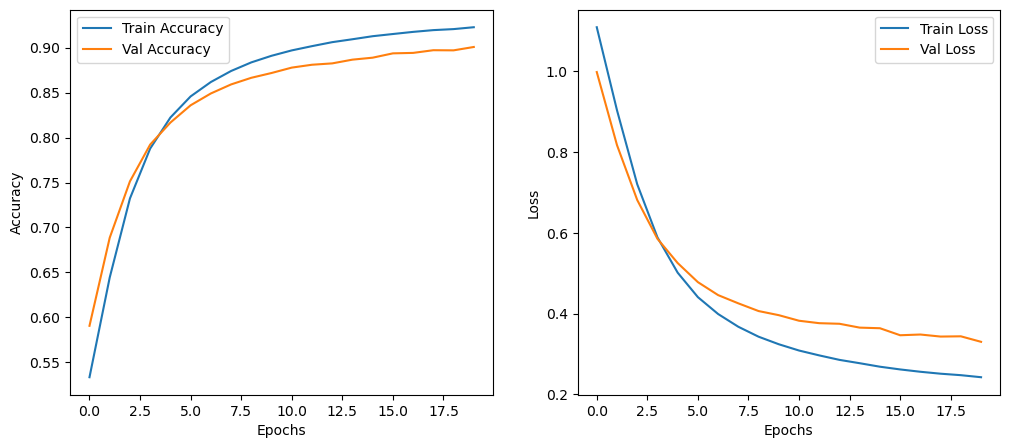

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [15]:

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(X_train_pad), axis=1)
y_true = np.argmax(y_train_cat, axis=1)

print(classification_report(y_true, y_pred))


54075/54075 ━━━━━━━━━━━━━━━━━━━━ 514s 10ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    346129
           1       0.98      0.98      0.98    345935
           2       0.96      0.97      0.96    346455
           3       0.91      0.90      0.90    345697
           4       0.92      0.90      0.91    346184

    accuracy                           0.95   1730400
   macro avg       0.95      0.95      0.95   1730400
weighted avg       0.95      0.95      0.95   1730400



In [16]:
import numpy as np

# پیش‌بینی احتمال‌ها
y_pred_proba = model.predict(X_val_pad, verbose=1)  

# پیدا کردن کلاس پیش‌بینی‌شده (argmax)
y_pred = np.argmax(y_pred_proba, axis=1)

# برچسب واقعی
y_true = np.argmax(y_val_cat, axis=1)


18025/18025 ━━━━━━━━━━━━━━━━━━━━ 354s 20ms/step


In [17]:
# ایندکس نمونه‌هایی که درست یا غلط پیش‌بینی شدن
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx   = np.where(y_pred != y_true)[0]

print(f"✅ تعداد پیش‌بینی درست: {len(correct_idx)}")
print(f"❌ تعداد پیش‌بینی غلط: {len(wrong_idx)}")


✅ تعداد پیش‌بینی درست: 519532
❌ تعداد پیش‌بینی غلط: 57268


In [ ]:
# تابع کمکی برای چاپ منظم
def show_examples(idxs, title):
    print(f"\n{'='*10} {title} {'='*10}")
    for i in idxs:
        print(f"\n📝 متن: {X_val_pad[i][:400]}...")  # نمایش ۴۰۰ کاراکتر اول
        print(f"🎯 درست: {y_true[i]} | 🔮 پیش‌بینی مدل: {y_pred[i]}")
        print("-"*60)

# انتخاب ۵ نمونه تصادفی از درست و غلط‌ها
np.random.seed(42)
correct_samples = np.random.choice(correct_idx, 5, replace=False)
wrong_samples   = np.random.choice(wrong_idx, 5, replace=False)

# نمایش
show_examples(correct_samples, "پیش‌بینی‌های صحیح")
show_examples(wrong_samples, "پیش‌بینی‌های غلط")



========== پیش‌بینی‌های صحیح ==========

📝 متن: [ 652   11   16    2  140    3   39   74  669    9    2 1318   16    6
  197  931    5  276    4  174   55   14  164    3   99  751   23    3
   99  808    2  197  160   10   21  326 1232   45  198  224    5  335
   15  238    0    0    0    0    0    0]...
🎯 درست: 4 | 🔮 پیش‌بینی مدل: 4
------------------------------------------------------------

📝 متن: [ 185 1629    4  294   35 1060  316 4244   35  373  341   16   12  691
  146  381    6 1729   47 2969  146   18   17   22 7176   22   29 1689
    5 1329    4   17   82   38    2  413  470  258  287  104   79  854
    2  591   37   47   68   70  167  171]...
🎯 درست: 0 | 🔮 پیش‌بینی مدل: 0
------------------------------------------------------------

📝 متن: [  64  109  302  267    4   49   93    4  166   35    6  590  160    4
    6 1854  381   22   51  203  188    4    1  361    9   33  301   64
    8    6  565   18   19  108    1  160    4  134    7   38    7   21
  167    7  385   38  53

In [ ]:
for i in wrong_samples:
    print("📝 متن:", X_val_pad[i])
    print("🎯 واقعی:", y_true[i], "🔮 پیش‌بینی:", y_pred[i])
    print("-"*80)
